# Policy Gradient Methods

Following Chapter *13* starting at page *321* from *Reinforcement Learning* (edition 2) by Andrew Barto and Richard S. Sutton.

Additionally, following:
- [DeepMind x UCL RL Lecture Series - Policy-Gradient and Actor-Critic methods 9/13](https://www.youtube.com/watch?v=y3oqOjHilio&list=PLqYmG7hTraZDVH599EItlEWsUOsJbAodm&index=11) 
- [RL Course by David Silver - Lecture 7: Policy Gradient Methods](https://www.youtube.com/watch?v=KHZVXao4qXs)

### Setup

In [5]:
import math
from datetime import datetime
import numpy as np
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.distributions import Categorical
from functools import partial
import gymnasium as gym

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.animation import FuncAnimation
from typing import Callable, Any, Optional
from IPython.display import HTML

from util.envs import GridMazeEnv, Action, State

### Gridworld

In [2]:
maze_grid = np.array([
    [0, 0, 0, 0, 0, 0, 0, 1, 3],
    [0, 0, 1, 0, 0, 0, 0, 1, 0],
    [2, 0, 1, 0, 0, 0, 0, 1, 0],
    [0, 0, 1, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 1, 0, 0, 0],
])

maze_env = GridMazeEnv(maze_grid)
maze_env

[[□ □ □ □ □ □ □ ■ G]
 [□ □ ■ □ □ □ □ ■ □]
 [S □ ■ □ □ □ □ ■ □]
 [□ □ ■ □ □ □ □ □ □]
 [□ □ □ □ □ □ □ □ □]
 [□ □ □ □ □ ■ □ □ □]]

In [2]:
def get_state_features_normalized(s: tuple[int, int], grid_shape: tuple[int, ...]) -> torch.Tensor:
    """Return normalized grid coords."""
    s_features = (s[0] / (grid_shape[0] - 1), s[1] / (grid_shape[1] - 1))
    return torch.Tensor(s_features)

def get_state_features_one_hot(s: tuple[int, int], grid_shape: tuple[int, ...]) -> torch.Tensor:
    """
    One-hot encoding of grid state. Equivalent to tabular representation.
    """
    H, W = grid_shape
    idx = s[0] * W + s[1]

    x = torch.zeros(H * W, dtype=torch.float32)
    x[idx] = 1.0
    return x

def get_state_features_local_grid(
    s: tuple[int, int],
    grid: np.ndarray,
    patch_size: int = 5,
    wall_value: int = 1,
    include_normalized_coords: bool = False
) -> torch.Tensor:
    """
    Local grid representation centred on the agent.

    Cells outside the environment are treated as walls.

    Args:
        s: Agent position (row, col).
        grid: Maze array.
        patch_size: Width/height of the local window (should be odd).
        wall_value: Value used to denote obstacles in the maze.
        include_normalized_coords: Whether to include the global normalized coords to the output vector (concatenated).

    Returns:
        Flattened binary tensor of shape (patch_size * patch_size,).
        1 = obstacle or outside map
        0 = free space
        x, y (floats) concatenated at the end of the flattened binary tensor - if include_normalized_coords is True.
    """
    if patch_size % 2 == 0:
        raise ValueError("patch_size must be odd.")

    radius = patch_size // 2

    # Binary occupancy map
    occupancy = (grid == wall_value).astype(np.float32)

    # Pad outside the map with obstacles
    padded = np.pad(
        occupancy,
        pad_width=radius,
        mode="constant",
        constant_values=1.0,
    )

    r, c = s
    r += radius
    c += radius

    patch = padded[
        r - radius : r + radius + 1,
        c - radius : c + radius + 1,
    ]

    patch_tensor = torch.from_numpy(patch.flatten())
    if include_normalized_coords:
        normalized_coords = get_state_features_normalized(s, grid.shape)
        return torch.concat((patch_tensor, normalized_coords))
    return patch_tensor

### REINFORCE - simple Policy Gradient using Monte Carlo sampling

As per intuition formed midway through lectures (before reading Sutton & Barto)

In [12]:
class PI_MLP(nn.Module):
    def __init__(self, state_dim: int, action_dim, hidden_dims: tuple[int, ...]):
        super().__init__()
        layers = [
            nn.Linear(state_dim, hidden_dims[0]), nn.ReLU(),
            ]
        for i in range(len(hidden_dims)-1):
            layers.append(nn.Linear(hidden_dims[i], hidden_dims[i+1]))
            layers.append(nn.ReLU())
        layers.append(nn.Linear(hidden_dims[-1], action_dim))
        self.network = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor):
        return self.network(x)

In [13]:
def _compute_discounted_returns(rewards: list[float], gamma: float) -> torch.Tensor:
    """
    Returns G_t = r_t + gamma * r_{t+1} + gamma^2 * r_{t+2} + ...
    for each timestep t in the episode.
    """
    returns = []
    G = 0.0
    for r in reversed(rewards):
        G = r + gamma * G
        returns.append(G)
    returns.reverse()
    return torch.tensor(returns, dtype=torch.float32)

In [14]:
def run_vanilla_policy_gradient(
    maze_env,
    gamma: float,
    alpha: float,
    num_epochs: int,
    max_steps: int,
    num_epochs_for_policy_objective: int,
    state_features_method: Callable,
    vfa_num_hiddle_layers: int
) -> tuple[PI_MLP, dict]:

    base_device = "cuda" if torch.cuda.is_available() else "cpu"
    grid_shape = maze_env.grid.shape
    num_actions = len(maze_env.action_set)

    # Infer feature dimension from some valid state representation.
    # This assumes the feature map has fixed size for all states.
    feature_dim = state_features_method(maze_env.goal_position, grid_shape).shape[0]

    pi_hat = PI_MLP(
        state_dim=feature_dim,
        action_dim=num_actions,
        hidden_dims=(num_actions * 2,) * vfa_num_hiddle_layers,
    ).to(base_device)

    optimizer = torch.optim.Adam(pi_hat.parameters(), lr=alpha)

    pbar = tqdm(range(num_epochs), desc="Policy Gradient")
    metrics = {
        "episode_lengths": [],
        "episode_returns": [],
        "losses": [],
    }

    successes = 0

    # Buffers for batched policy updates
    batch_log_probs: list[torch.Tensor] = []
    batch_returns: list[torch.Tensor] = []

    device = next(pi_hat.parameters()).device

    for ep_idx in pbar:
        s = maze_env.reset()

        episode_log_probs: list[torch.Tensor] = []
        episode_rewards: list[float] = []

        episode_steps = 0
        episode_return = 0.0

        for step in range(max_steps):
            phi_s = torch.as_tensor(
                state_features_method(s, grid_shape),
                dtype=torch.float32,
                device=device,
            )

            logits = pi_hat(phi_s)
            dist = Categorical(logits=logits) # distribution to sample from (policy prob)

            a = dist.sample()
            log_prob = dist.log_prob(a)

            _, s_prime, done = maze_env.step(int(a.item()))

            # Reward adjustment for grid maze
            r = 5.0 if done else -0.01 # done else step penalty

            episode_log_probs.append(log_prob)
            episode_rewards.append(r)

            episode_return += r
            s = s_prime
            episode_steps = step + 1

            if done:
                successes += 1
                break

        # Compute return-to-go for every action in this episode
        returns = _compute_discounted_returns(episode_rewards, gamma).to(device)

        # Save trajectory data for a batched update
        batch_log_probs.append(torch.stack(episode_log_probs))
        batch_returns.append(returns)

        # Update policy every N episodes
        if (ep_idx + 1) % num_epochs_for_policy_objective == 0:
            all_log_probs = torch.cat(batch_log_probs)
            all_returns = torch.cat(batch_returns)

            # Variance stabilisation: standardise returns
            if all_returns.numel() > 1:
                all_returns = (all_returns - all_returns.mean()) / (all_returns.std(unbiased=False) + 1e-8)
            else:
                all_returns = all_returns - all_returns.mean()

            # REINFORCE loss: maximise E[log pi(a|s) * G]
            # so we minimise the negative
            loss = -(all_log_probs * all_returns.detach()).mean()

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(pi_hat.parameters(), max_norm=1.0)
            optimizer.step()

            metrics["losses"].append(float(loss.item()))

            batch_log_probs.clear()
            batch_returns.clear()

        metrics["episode_lengths"].append(episode_steps)
        metrics["episode_returns"].append(episode_return)

        pbar.set_postfix(
            successes=f"{successes}/{ep_idx + 1}",
            steps=episode_steps,
            return_=f"{episode_return:.3f}",
            loss=f"{metrics['losses'][-1]:.4f}" if metrics["losses"] else "n/a",
        )

    return pi_hat, metrics

In [15]:
alpha = 3e-4
gamma = 0.995
num_epochs = 1000
max_steps = 200
policy_batch_num_epochs = 1
state_feature_method: Callable = lambda s, grid_shape: get_state_features_local_grid(s, maze_env.grid, patch_size=5, include_normalized_coords=True)
num_hidden_layers = 2

pi_hat, metrics = run_vanilla_policy_gradient(
    maze_env, 
    gamma, 
    alpha, 
    num_epochs, 
    max_steps,
    policy_batch_num_epochs, 
    state_feature_method, 
    num_hidden_layers
    )

Policy Gradient: 100%|██████████| 1000/1000 [02:00<00:00,  8.33it/s, loss=-0.0072, return_=-2.000, steps=200, successes=129/1000]


In [11]:
# Preview leared probs for a state
# These should be relatively sharp
with torch.no_grad():
    phi_s = state_feature_method(State((0, 2)), None)
    logits = pi_hat(phi_s)
    probs = torch.softmax(logits, dim=-1)
    print(probs)

tensor([0.1981, 0.4426, 0.2471, 0.1122])


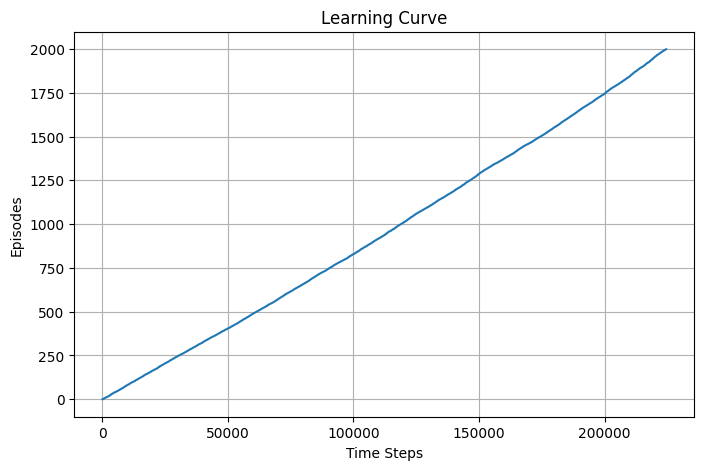

In [12]:
maze_env.plot_time_steps_per_episode(metrics["episode_lengths"])

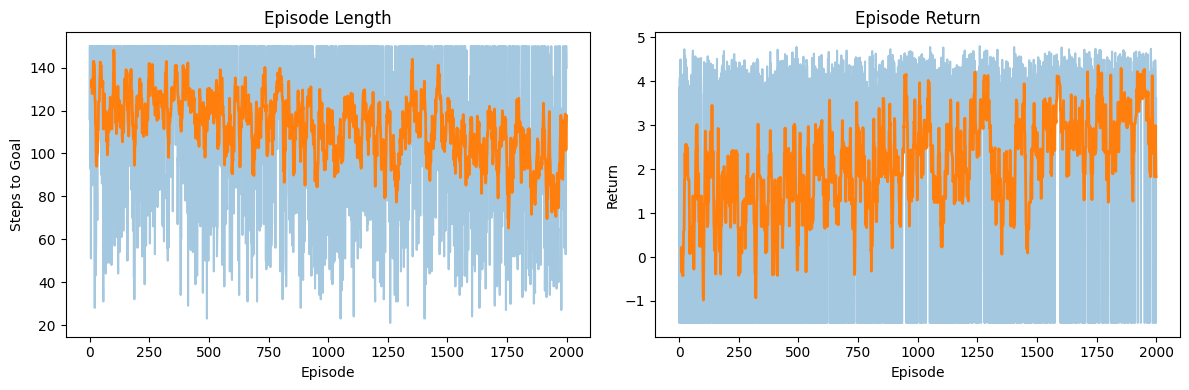

In [13]:
maze_env.plot_training_metrics(metrics["episode_lengths"], metrics["episode_returns"])

### CartPole - REINFORCE

https://gymnasium.farama.org/environments/classic_control/cart_pole/

The action is a ndarray with shape (1,) which can take values {0, 1} indicating the direction of the fixed force the cart is pushed with.

0: Push cart to the left

1: Push cart to the right

Note: The velocity that is reduced or increased by the applied force is not fixed and it depends on the angle the pole is pointing. The center of gravity of the pole varies the amount of energy needed to move the cart underneath it

The observation is a ndarray with shape (4,) with the values corresponding to the following positions and velocities:  
0 - cart position  
1 - cart velocity  
2 - pole angle  
3 - pole angular velocity  

In [6]:
def plot_reinforce_metrics(metrics: dict, window: int = 50):
    """
    Visualize training metrics from an episodic REINFORCE run.

    Parameters
    ----------
    metrics:
        Dictionary containing:
            - "episode_lengths"
            - "episode_returns"
            - "losses"

    window:
        Moving-average window used for smoothing.
    """

    returns = np.asarray(metrics["episode_returns"], dtype=float)
    lengths = np.asarray(metrics["episode_lengths"], dtype=float)
    losses = np.asarray(metrics["losses"], dtype=float)

    episodes = np.arange(1, len(returns) + 1)

    def moving_average(x, window):
        if len(x) < window:
            return np.array([])
        return np.convolve(
            x,
            np.ones(window) / window,
            mode="valid",
        )

    # ---------------------------------------------------------
    # Compute smoothed quantities
    # ---------------------------------------------------------

    returns_ma = moving_average(returns, window)
    lengths_ma = moving_average(lengths, window)
    losses_ma = moving_average(losses, window)

    ma_episodes = np.arange(window, len(returns) + 1)

    # ---------------------------------------------------------
    # Plot
    # ---------------------------------------------------------

    fig, axes = plt.subplots(
        3,
        1,
        figsize=(12, 12),
        sharex=True,
    )

    # =========================================================
    # 1. Episode return
    # =========================================================

    axes[0].plot(
        episodes,
        returns,
        alpha=0.25,
        label="Episode return",
    )

    if len(returns_ma):
        axes[0].plot(
            ma_episodes,
            returns_ma,
            linewidth=2,
            label=f"{window}-episode moving average",
        )

    axes[0].set_ylabel("Return")
    axes[0].set_title("REINFORCE learning curve")
    axes[0].legend()
    axes[0].grid(alpha=0.2)

    # =========================================================
    # 2. Episode length
    # =========================================================

    axes[1].plot(
        episodes,
        lengths,
        alpha=0.25,
        label="Episode length",
    )

    if len(lengths_ma):
        axes[1].plot(
            ma_episodes,
            lengths_ma,
            linewidth=2,
            label=f"{window}-episode moving average",
        )

    axes[1].set_ylabel("Steps")
    axes[1].set_title("Episode length")
    axes[1].legend()
    axes[1].grid(alpha=0.2)

    # =========================================================
    # 3. Policy-gradient loss
    # =========================================================

    axes[2].plot(
        episodes,
        losses,
        alpha=0.25,
        label="Loss",
    )

    if len(losses_ma):
        axes[2].plot(
            ma_episodes,
            losses_ma,
            linewidth=2,
            label=f"{window}-episode moving average",
        )

    axes[2].set_xlabel("Episode")
    axes[2].set_ylabel("Loss")
    axes[2].set_title("REINFORCE loss")
    axes[2].legend()
    axes[2].grid(alpha=0.2)

    plt.tight_layout()
    plt.show()

In [7]:
env = gym.make("CartPole-v1", render_mode="rgb_array")
env

<TimeLimit<OrderEnforcing<PassiveEnvChecker<CartPoleEnv<CartPole-v1>>>>>

In [8]:
env.reset()

(array([ 0.03735795, -0.04073098, -0.02660098, -0.01965699], dtype=float32),
 {})

In [9]:
action = np.array((1))
obs, reward, terminated, truncated, info = env.step(action)
print("obs: ", obs)
print("reward:", reward)
print("terminated: ", terminated)
print("truncated: ", truncated)
print("info: ", info)

obs:  [ 0.03654333  0.15476215 -0.02699412 -0.32061273]
reward: 1.0
terminated:  False
truncated:  False
info:  {}


In [15]:
# Preview architecture
pi_hat = PI_MLP(state_dim=4, action_dim=2, hidden_dims=(4,))
pi_hat

PI_MLP(
  (network): Sequential(
    (0): Linear(in_features=4, out_features=4, bias=True)
    (1): ReLU()
    (2): Linear(in_features=4, out_features=2, bias=True)
  )
)

In [ ]:
gamma = 1.0
alpha = 5e-4
num_episodes = 5000

save_checkpoint = True
store_metrics_every_n = 50

pi_hat = PI_MLP(state_dim=4, action_dim=2, hidden_dims=(4,))
optimizer = torch.optim.Adam(pi_hat.parameters(), lr=alpha)
pbar = tqdm(range(num_episodes), desc="CartPole REINFORCE")
metrics = {
    "episode_lengths": [],
    "episode_returns": [],
    "losses": [],
}

successes = 0
for ep_idx in pbar:
    obs, info = env.reset()

    episode_log_probs: list[torch.Tensor] = []
    episode_rewards: list[float | Any] = []

    # --- Episode rollout ---
    episode_return = 0.0
    while True:
        s = torch.as_tensor(obs, dtype=torch.float32) # state from observation - in this case, the state IS the observation
        logits = pi_hat(s)
        dist = Categorical(logits=logits)
        a = dist.sample() # tensor-wrapped action index - in this case, a 0 or 1
        log_prob = dist.log_prob(a)

        obs_prime, r, terminated, truncated, info = env.step(a.numpy())

        episode_log_probs.append(log_prob)
        episode_rewards.append(r)

        obs = obs_prime

        # housekeeping
        episode_return += float(r)
        if truncated:
            successes += 1
        if terminated or truncated:
            break

    # --- Learning ---
    all_returns = _compute_discounted_returns(episode_rewards, gamma) # compute returns at every timestep
    # Normalize the returns - to reduce gradient variance
    all_returns = (all_returns - all_returns.mean()) / (all_returns.std() + 1e-8)

    all_log_probs = torch.stack(episode_log_probs)
    loss = -(all_returns * all_log_probs).sum() # element-wise multiplication (Hadamard product); alpha is applied by optimizer. negation is applied to ensure gradient ascent

    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()
    # --- Housekeeping ---
    episode_length = len(episode_rewards)
    if ep_idx & store_metrics_every_n == 0:
        metrics["episode_lengths"].append(episode_length)
        metrics["episode_returns"].append(episode_return)
        metrics["losses"].append(float(loss.item()))
    pbar.set_postfix(
        successes=f"{successes}/{ep_idx + 1}",
        steps=episode_length,
        return_=f"{episode_return:.3f}",
        loss=f"{metrics['losses'][-1]:.4f}" if metrics["losses"] else "n/a",
    )

# --- Checkpoint saving ---
if save_checkpoint:
    checkpoints_dir = "../../runtime/checkpoints"
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    checkpoint = {
        'episode': num_episodes,
        'model_state_dict': pi_hat.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': metrics['losses'][-1]
    }
    filename = f"REINFORCE_pi_hat_checkpoint_{timestamp}.pth"
    save_path = f"{checkpoints_dir}/{filename}"
    torch.save(checkpoint, save_path)
    print(f"Model successfully saved at: {save_path}")

CartPole REINFORCE: 100%|██████████| 5000/5000 [09:51<00:00,  8.46it/s, loss=-0.1079, return_=500.000, steps=500, successes=1318/5000] 

Model successfully saved as: REINFORCE_pi_hat_checkpoint_20260826_165804.pth


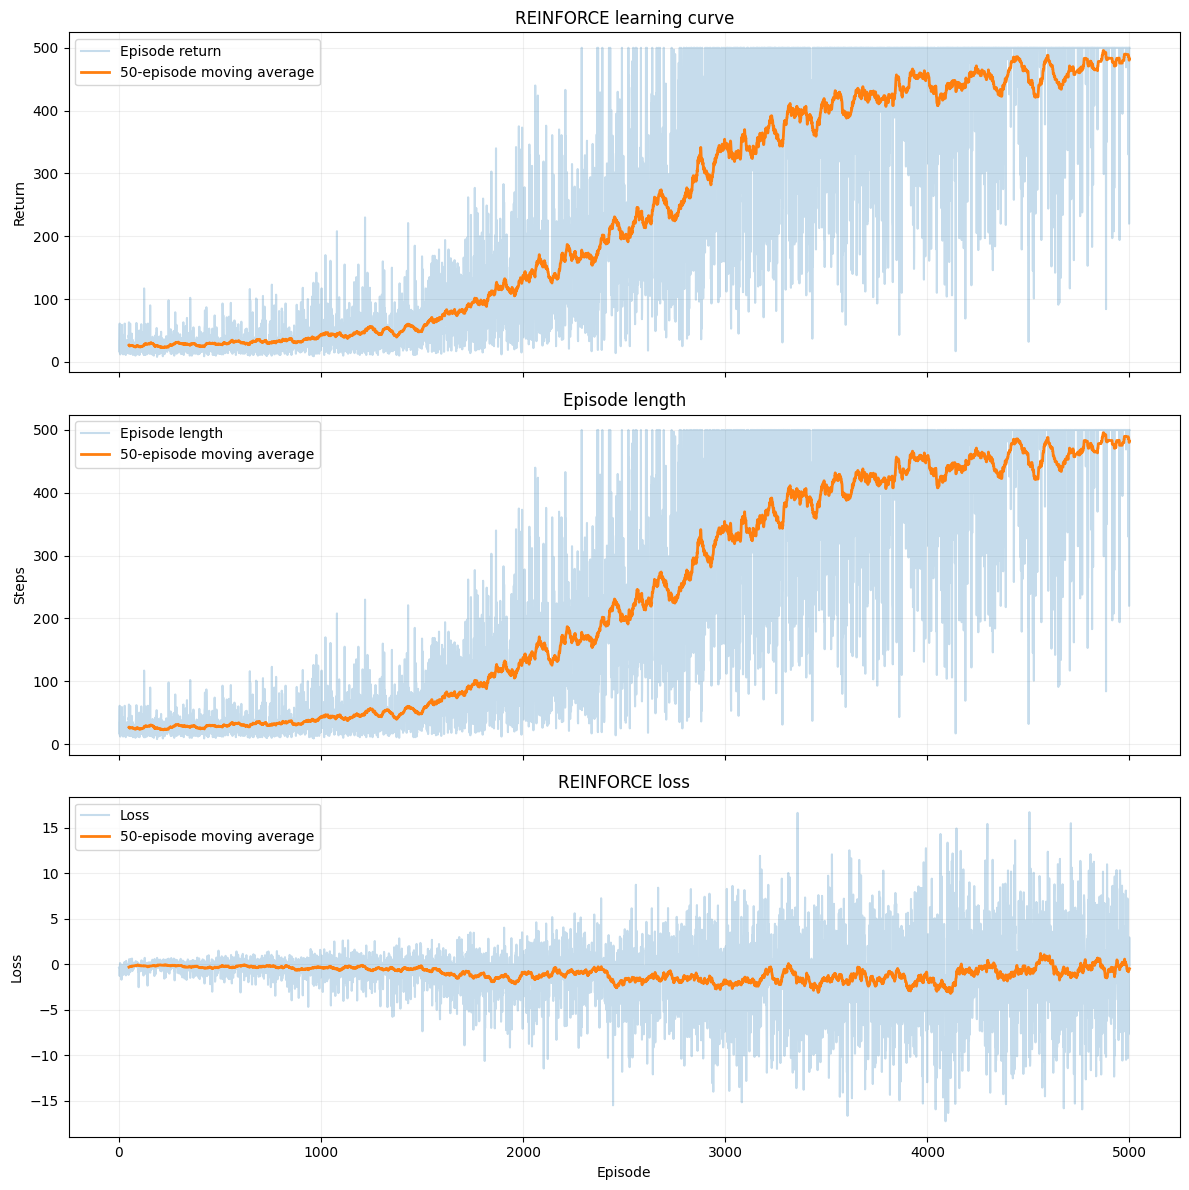

In [20]:
plot_reinforce_metrics(metrics, window=50)

In [22]:
def visualize_episode(pi_hat, env, stochastic=True):
    """
    Run one episode using the trained policy and render it.

    stochastic=True:
        Sample actions from pi_theta(a|s), as during training.

    stochastic=False:
        Always choose the highest-probability action.
        Useful for evaluating the learned policy.
    """
    pi_hat.eval()

    obs, info = env.reset()

    episode_return = 0.0
    episode_length = 0

    with torch.no_grad():
        while True:
            state = torch.as_tensor(obs, dtype=torch.float32)

            logits = pi_hat(state)
            dist = Categorical(logits=logits)

            if stochastic:
                action = dist.sample()
            else:
                action = torch.argmax(logits)

            obs, reward, terminated, truncated, info = env.step(
                action.item()
            )

            episode_return += reward
            episode_length += 1

            if terminated or truncated:
                break

    print(f"Return: {episode_return:.0f}")
    print(f"Episode length: {episode_length}")

    pi_hat.train()

    return episode_return, episode_length

In [23]:
eval_env = gym.make("CartPole-v1", render_mode="human")
visualize_episode(pi_hat, eval_env, stochastic=False)
eval_env.close()

Return: 500
Episode length: 500


### REINFORCE with Baseline

TO DO